# Generating Networks with Arbitrary Degree Distribution

Corresponding to Chapter 4.8 in the book [Network Science Book](https://www.networksciencebook.com/) by Albert-László Barabási



In [1]:
!pip install numpy pandas matplotlib networkx scipy 

## Overview

In this notebook, we explore three fundamental methods for generating networks that preserve a given degree distribution:

1. **Configuration Model**: Generates a random graph with exactly the specified degree sequence
2. **Random Swap (Randomization)**: Starts with an observed network and randomly swaps edges while preserving degrees
3. **Hidden Variable Model**: Generates a network where connection probability depends on node "hidden variables" related to their degrees

These methods are crucial for:
- Creating null models for statistical testing
- Understanding how much of a network's structure is determined solely by its degree distribution
- Generating synthetic networks with realistic degree properties

We'll use the **Facebook social network** as our example to extract a real degree sequence and see how each method reproduces (or modifies) the network properties.


In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Set style for consistent visualizations
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Create output directory
import os
os.makedirs('./figures', exist_ok=True)

print("Imports successful. Ready to generate networks with degree distributions.")

Imports successful. Ready to generate networks with degree distributions.


## Step 1: Load and Analyze the Facebook Network

We'll use the Facebook social network as our empirical degree distribution source. This network captures friendships among Facebook users.


In [3]:
# Load the Facebook social network
G_facebook = nx.read_edgelist('./Data/facebook_combined.txt')

# Basic network statistics
n_nodes = G_facebook.number_of_nodes()
n_edges = G_facebook.number_of_edges()
avg_degree = 2 * n_edges / n_nodes

print(f"Facebook Network Properties:")
print(f"  Nodes: {n_nodes}")
print(f"  Edges: {n_edges}")
print(f"  Average degree: {avg_degree:.2f}")
print(f"  Density: {nx.density(G_facebook):.4f}")

# Extract degree sequence
deg_sequence = [G_facebook.degree(n) for n in G_facebook.nodes()]
deg_sequence = np.array(deg_sequence)

print(f"\nDegree Sequence Statistics:")
print(f"  Min degree: {deg_sequence.min()}")
print(f"  Max degree: {deg_sequence.max()}")
print(f"  Mean degree: {deg_sequence.mean():.2f}")
print(f"  Median degree: {np.median(deg_sequence):.2f}")

Facebook Network Properties:
  Nodes: 4039
  Edges: 88234
  Average degree: 43.69
  Density: 0.0108

Degree Sequence Statistics:
  Min degree: 1
  Max degree: 1045
  Mean degree: 43.69
  Median degree: 25.00


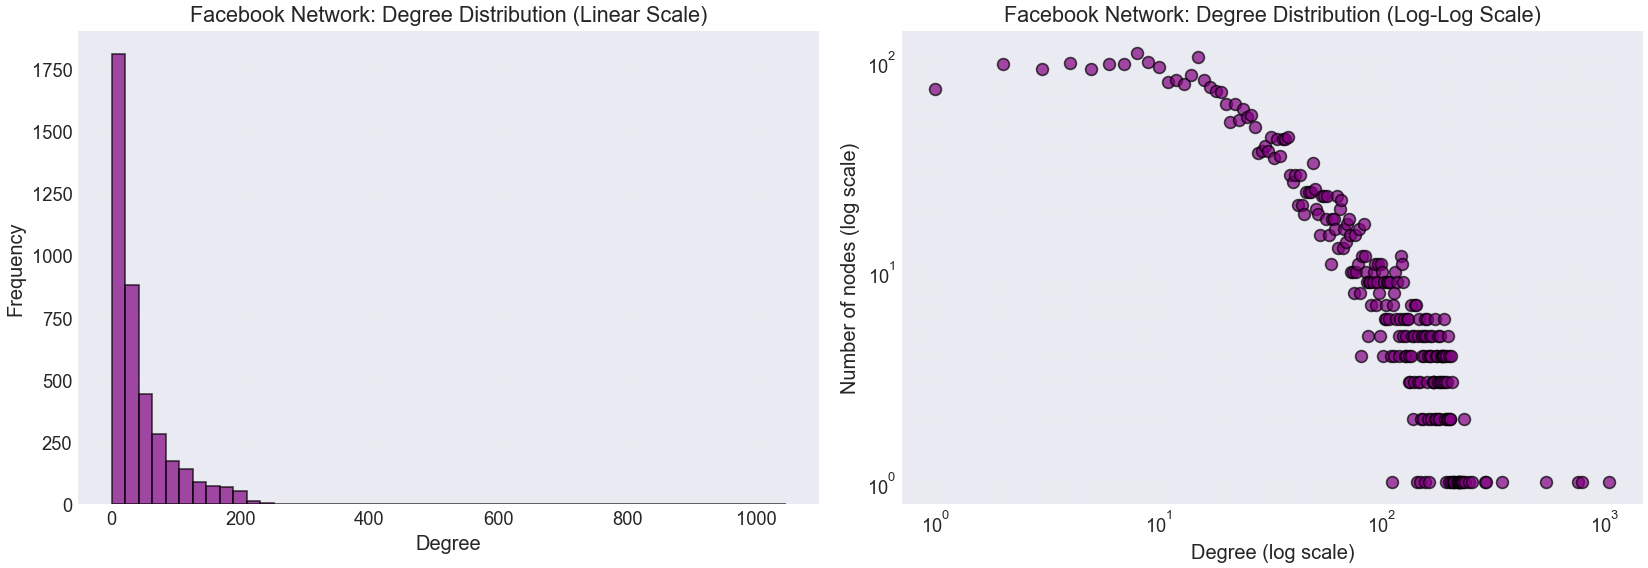

Facebook degree sequence extracted. Ready for network generation.


In [4]:
# Visualize the empirical degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale histogram
axes[0].hist(deg_sequence, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Degree', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Facebook Network: Degree Distribution (Linear Scale)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Log-log scale scatter plot (binned)
degree_counts = np.bincount(deg_sequence)
degrees = np.nonzero(degree_counts)[0]
counts = degree_counts[degrees]

# Filter out zero counts and plot on log-log scale
valid_idx = counts > 0
axes[1].scatter(degrees[valid_idx], counts[valid_idx], s=50, color='purple', alpha=0.7, edgecolors='black', linewidth=1)
axes[1].set_xlabel('Degree (log scale)', fontsize=12)
axes[1].set_ylabel('Number of nodes (log scale)', fontsize=12)
axes[1].set_title('Facebook Network: Degree Distribution (Log-Log Scale)', fontsize=13)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('./figures/01_facebook_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Facebook degree sequence extracted. Ready for network generation.")

## Step 2: Method 1 - Configuration Model

The **Configuration Model** is a random graph model that generates a network with exactly the specified degree sequence. It works by:

1. Creating "stubs" (half-edges) for each node according to its target degree
2. Randomly pairing these stubs to form edges

**Key properties:**
- Preserves exact degree sequence
- Creates a random graph otherwise (no clustering, short paths)
- May produce multi-edges or self-loops (which we'll remove)
- Computationally efficient


In [5]:
# Method 1: Configuration Model
print("Generating network with Configuration Model...")
G_conf = nx.configuration_model(deg_sequence.tolist(), seed=42)

# Convert to simple graph (remove multi-edges and self-loops)
G_conf = nx.Graph(G_conf)

print(f"Configuration Model Network:")
print(f"  Nodes: {G_conf.number_of_nodes()}")
print(f"  Edges: {G_conf.number_of_edges()}")
print(f"  Average degree: {2 * G_conf.number_of_edges() / G_conf.number_of_nodes():.2f}")

# Get degree sequence
deg_conf = np.array([G_conf.degree(n) for n in G_conf.nodes()])
print(f"  Degree stats: min={deg_conf.min()}, max={deg_conf.max()}, mean={deg_conf.mean():.2f}")

Generating network with Configuration Model...


Configuration Model Network:
  Nodes: 4039
  Edges: 85607
  Average degree: 42.39
  Degree stats: min=1, max=793, mean=42.39


## Step 3: Method 2 - Random Swap (Randomization)

The **Random Swap** method (also called edge swapping or randomization) starts with the observed network and randomly rewires edges while preserving the degree of every node.

**How it works:**
1. Start with the original network
2. Randomly select two edges: (u,v) and (x,y) where u,v,x,y are distinct
3. Swap them to create (u,x) and (v,y) - this preserves all degrees
4. Repeat many times

**Key properties:**
- Preserves exact degree sequence (always)
- Produces a random rewiring of the original network
- The resulting network retains the connectivity of the original
- Useful for creating null models while maintaining degree structure


In [6]:
# Method 2: Random Swap (edge swapping)
print("\nGenerating network with Random Swap...")
G_swap = G_facebook.copy()

# Perform random edge swaps
np.random.seed(42)
nx.double_edge_swap(G_swap, nswap=20, max_tries=200, seed=42)

print(f"Random Swap Network:")
print(f"  Nodes: {G_swap.number_of_nodes()}")
print(f"  Edges: {G_swap.number_of_edges()}")
print(f"  Average degree: {2 * G_swap.number_of_edges() / G_swap.number_of_nodes():.2f}")

# Get degree sequence
deg_swap = np.array([G_swap.degree(n) for n in G_swap.nodes()])
print(f"  Degree stats: min={deg_swap.min()}, max={deg_swap.max()}, mean={deg_swap.mean():.2f}")

# Verify degree sequence is preserved
print(f"\nDegree sequence verification:")
print(f"  Original Facebook degree sum: {deg_sequence.sum()}")
print(f"  Swapped network degree sum: {deg_swap.sum()}")
print(f"  Match: {np.array_equal(np.sort(deg_sequence), np.sort(deg_swap))}")


Generating network with Random Swap...
Random Swap Network:
  Nodes: 4039
  Edges: 88234
  Average degree: 43.69
  Degree stats: min=1, max=1045, mean=43.69

Degree sequence verification:
  Original Facebook degree sum: 176468
  Swapped network degree sum: 176468


  Match: True


## Step 4: Method 3 - Hidden Variable Model (Expected Degree Graph)

The **Hidden Variable Model** generates a random graph where the connection probability between nodes depends on "hidden variables" - often interpreted as node "fitness" or "strength" related to degree.

**How it works:**
1. Assign a hidden variable to each node (related to its target degree)
2. The probability of connecting two nodes depends on their hidden variables
3. This creates a network where high-degree nodes are more likely to connect

**Key properties:**
- Does NOT necessarily preserve exact degree sequence (probabilistic)
- Creates clustering and other realistic features
- Fast to generate even for large networks
- Good null model that's more realistic than configuration model


In [7]:
# Method 3: Hidden Variable Model (Expected Degree Graph)
print("\nGenerating network with Hidden Variable Model (Expected Degree Graph)...")
G_exp = nx.expected_degree_graph(deg_sequence.tolist(), selfloops=False, seed=42)

print(f"Hidden Variable Model Network:")
print(f"  Nodes: {G_exp.number_of_nodes()}")
print(f"  Edges: {G_exp.number_of_edges()}")
print(f"  Average degree: {2 * G_exp.number_of_edges() / G_exp.number_of_nodes():.2f}")

# Get degree sequence
deg_exp = np.array([G_exp.degree(n) for n in G_exp.nodes()])
print(f"  Degree stats: min={deg_exp.min()}, max={deg_exp.max()}, mean={deg_exp.mean():.2f}")

print(f"\nNote: This method does NOT preserve exact degrees (it's probabilistic)")
print(f"  Original mean degree: {deg_sequence.mean():.2f}")
print(f"  Expected model mean degree: {deg_exp.mean():.2f}")
print(f"  Difference: {abs(deg_sequence.mean() - deg_exp.mean()):.2f}")


Generating network with Hidden Variable Model (Expected Degree Graph)...
Hidden Variable Model Network:
  Nodes: 4039
  Edges: 88139
  Average degree: 43.64
  Degree stats: min=0, max=1036, mean=43.64

Note: This method does NOT preserve exact degrees (it's probabilistic)
  Original mean degree: 43.69
  Expected model mean degree: 43.64
  Difference: 0.05


## Step 5: Comparison - Degree Distributions

Now let's compare the degree distributions of all four networks (original Facebook and the three generated networks).


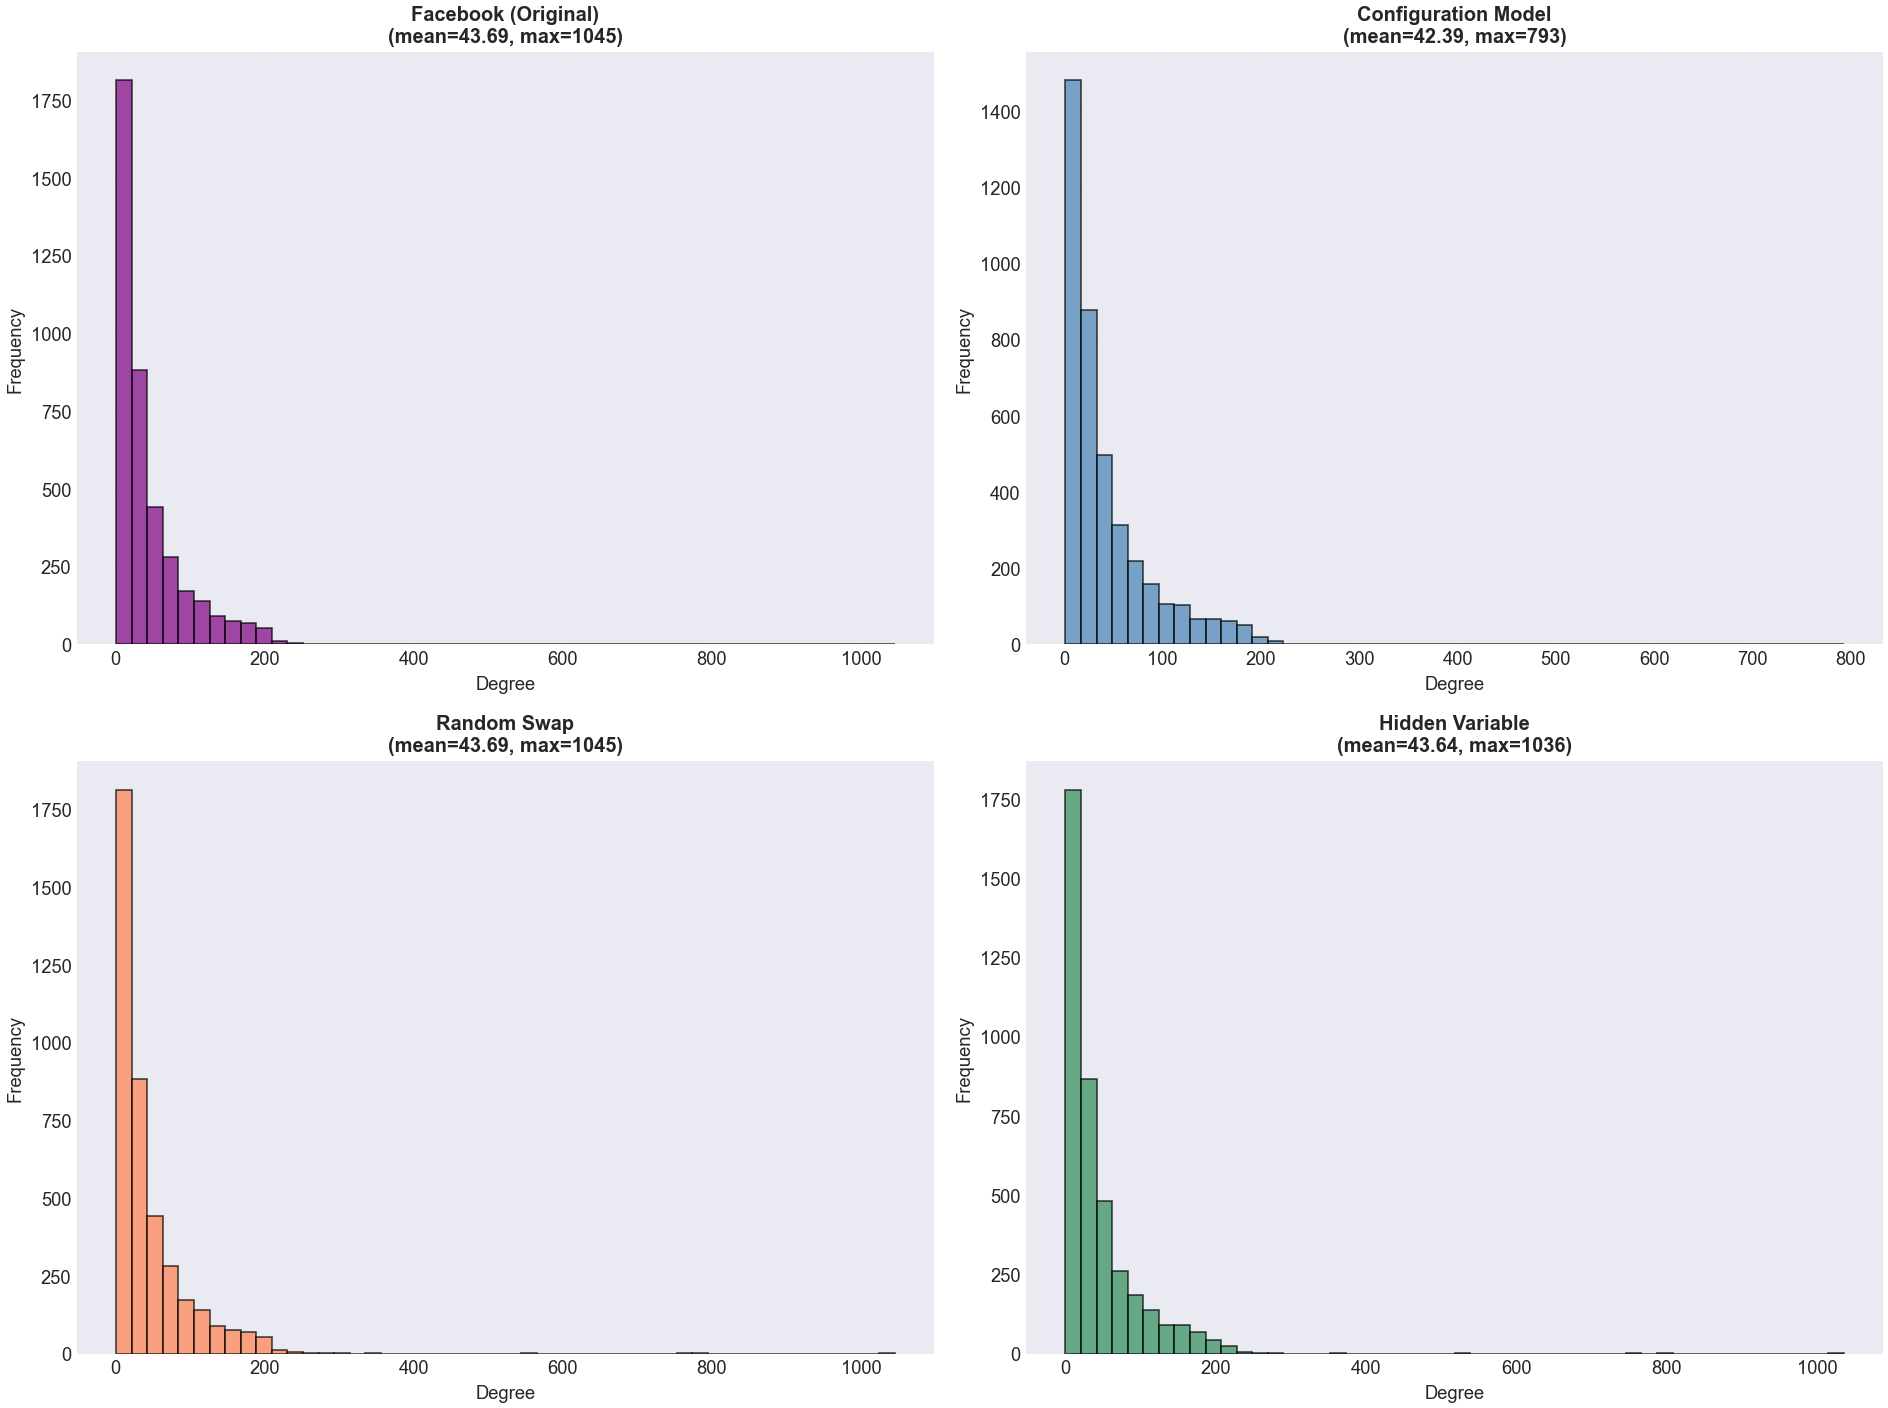

Linear scale degree distributions plotted.


In [8]:
# Compare degree distributions - Linear Scale
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

networks = {
    'Facebook (Original)': deg_sequence,
    'Configuration Model': deg_conf,
    'Random Swap': deg_swap,
    'Hidden Variable': deg_exp
}

colors = ['purple', 'steelblue', 'coral', 'seagreen']

for idx, (ax, (name, deg)) in enumerate(zip(axes.flat, networks.items())):
    ax.hist(deg, bins=50, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_xlabel('Degree', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\n(mean={deg.mean():.2f}, max={deg.max()})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/02_degree_distributions_linear.png', dpi=150, bbox_inches='tight')
plt.show()

print("Linear scale degree distributions plotted.")

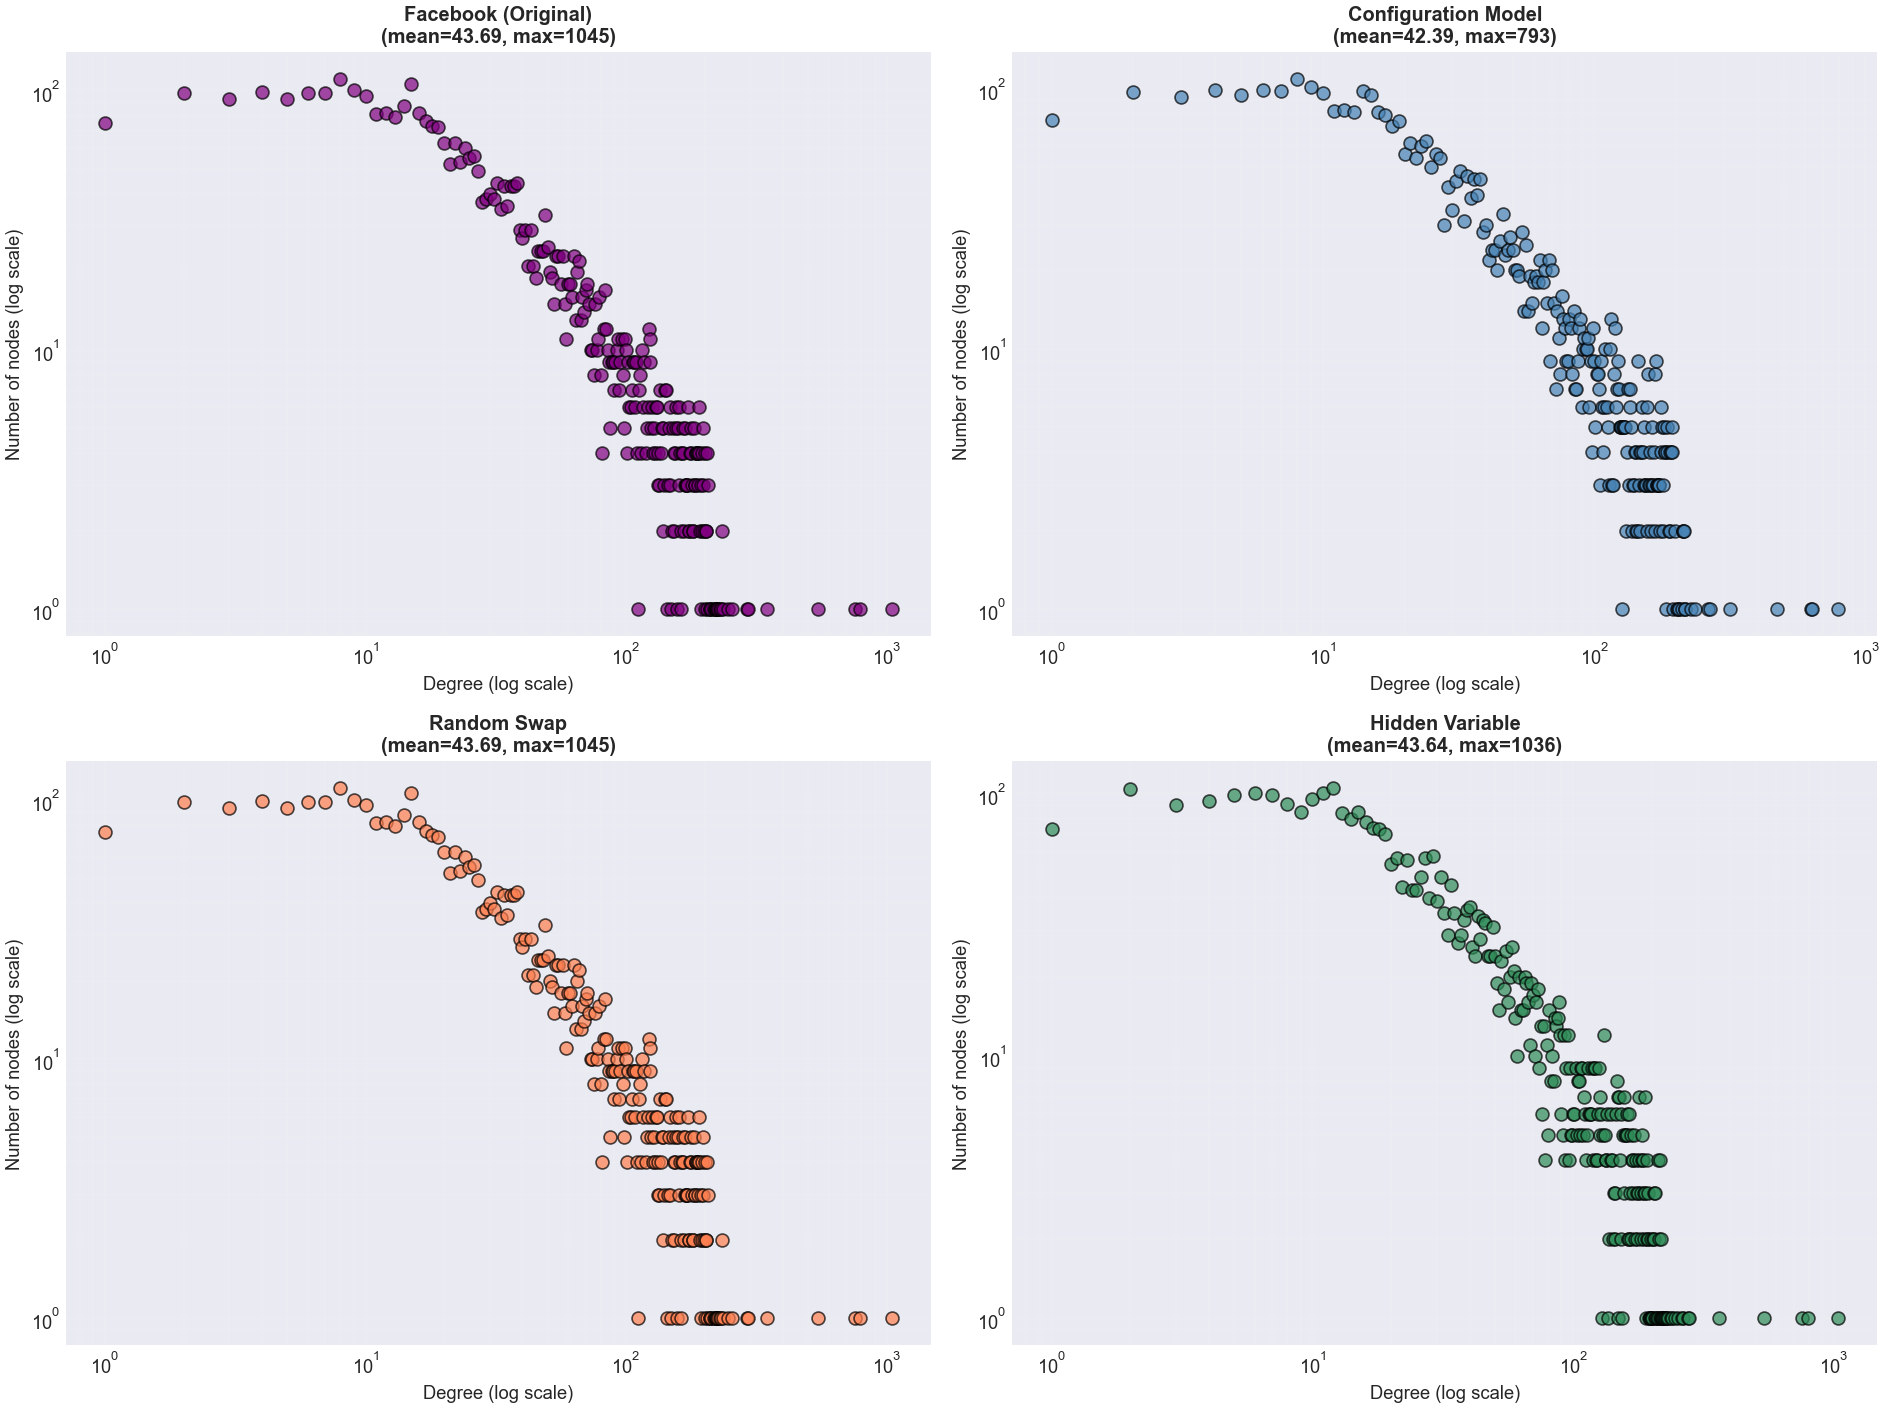

Log-log scale degree distributions plotted.


In [9]:
# Compare degree distributions - Log-Log Scale
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (ax, (name, deg)) in enumerate(zip(axes.flat, networks.items())):
    degree_counts = np.bincount(deg)
    degrees = np.nonzero(degree_counts)[0]
    counts = degree_counts[degrees]
    
    # Filter out zero counts
    valid_idx = counts > 0
    
    ax.scatter(degrees[valid_idx], counts[valid_idx], s=60, color=colors[idx], 
               alpha=0.7, edgecolors='black', linewidth=1)
    ax.set_xlabel('Degree (log scale)', fontsize=11)
    ax.set_ylabel('Number of nodes (log scale)', fontsize=11)
    ax.set_title(f'{name}\n(mean={deg.mean():.2f}, max={deg.max()})', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('./figures/03_degree_distributions_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log-log scale degree distributions plotted.")

## Step 6: Comparison - Network Properties

Beyond degree distributions, different generation methods preserve different network properties. Let's compute and compare key metrics for all four networks.


## Step 7: Extended Comparison - Additional Network Properties

Beyond the basic metrics, let's analyze three additional important network properties that can reveal deeper structural differences:

### 1. **Assortativity** 
Measures the degree correlation between connected nodes. It ranges from -1 to +1:
- **Positive**: Assortative networks where high-degree nodes connect to other high-degree nodes (homophily)
- **Negative**: Disassortative networks where high-degree nodes connect to low-degree nodes
- **Zero**: No correlation in degrees between neighbors

Social networks tend to be assortative, while technological networks are often disassortative.

### 2. **Transitivity (Global Clustering Coefficient)**
The network-wide version of clustering coefficient - the probability that two neighbors of a node are also neighbors of each other. This captures the prevalence of triangles in the network.
- Differs from local clustering coefficient (which we already computed)
- Global measure that accounts for the overall triangle structure

### 3. **Average Neighbor Degree**
For each node, measure the average degree of its neighbors. This reveals:
- If hub nodes (high-degree) connect to other hubs (assortative mixing)
- If hub nodes connect to peripheral nodes (disassortative mixing)
- Network connectivity patterns at different scales

In [ ]:
# Calculate additional network properties
def compute_extended_properties(G, name):
    """Compute extended network properties including assortativity, transitivity, and neighbor degree"""
    
    # Basic properties
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    # Assortativity coefficient
    assortativity = nx.degree_assortativity_coefficient(G)
    
    # Transitivity (global clustering coefficient)
    transitivity = nx.transitivity(G)
    
    # Average neighbor degree
    avg_neighbor_degree = nx.average_neighbor_degree(G)
    avg_neighbor_degree_mean = np.mean(list(avg_neighbor_degree.values()))
    
    return {
        'Network': name,
        'Assortativity': assortativity,
        'Transitivity': transitivity,
        'Avg Neighbor Degree': avg_neighbor_degree_mean
    }

# Compute extended properties for all networks
print("Computing extended network properties (this may take a moment)...")
extended_properties = [
    compute_extended_properties(G_facebook, 'Facebook (Original)'),
    compute_extended_properties(G_conf, 'Configuration Model'),
    compute_extended_properties(G_swap, 'Random Swap'),
    compute_extended_properties(G_exp, 'Hidden Variable Model')
]

df_extended = pd.DataFrame(extended_properties)

print("\n" + "="*100)
print("EXTENDED NETWORK PROPERTIES")
print("="*100)
print(df_extended.to_string(index=False))
print("="*100)

In [ ]:
# Create comprehensive comparison table
print("\n" + "="*140)
print("COMPREHENSIVE NETWORK PROPERTIES COMPARISON")
print("="*140)

# Merge basic and extended properties
df_comparison = df_properties.copy()
for col in ['Assortativity', 'Transitivity', 'Avg Neighbor Degree']:
    df_comparison[col] = df_extended[col]

# Reorder columns for better presentation
column_order = ['Network', 'Nodes', 'Edges', 'Avg Degree', 'Density', 
                'Clustering Coeff', 'Transitivity', 'Avg Path Length', 
                'Assortativity', 'Avg Neighbor Degree', 'Num Components', 'Largest CC %']
df_comparison = df_comparison[column_order]

# Display with custom formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if x < 10 else f'{x:.1f}')

print(df_comparison.to_string(index=False))
print("="*140)

# Analysis of differences
print("\n" + "="*140)
print("INTERPRETATION OF EXTENDED PROPERTIES")
print("="*140)

fb_extended = extended_properties[0]

print(f"""
ASSORTATIVITY ANALYSIS:
""")
for method, props in zip(['Configuration Model', 'Random Swap', 'Hidden Variable'], extended_properties[1:]):
    diff = props['Assortativity'] - fb_extended['Assortativity']
    print(f"  {method:20s}: {props['Assortativity']:7.4f} (Δ {diff:+.4f})")

print(f"""
  → Facebook shows positive assortativity ({fb_extended['Assortativity']:.4f}): friends of well-connected users 
    are likely to be well-connected themselves (homophily/assortative mixing)
  → Configuration model and Hidden Variable model lose this property (near-zero assortativity)
  → Random Swap preserves the original assortativity pattern

TRANSITIVITY (Global Clustering):
""")
for method, props in zip(['Configuration Model', 'Random Swap', 'Hidden Variable'], extended_properties[1:]):
    diff = props['Transitivity'] - fb_extended['Transitivity']
    print(f"  {method:20s}: {props['Transitivity']:7.4f} (Δ {diff:+.4f})")

print(f"""
  → Facebook's transitivity ({fb_extended['Transitivity']:.4f}) reflects high local clustering
  → Configuration model and Hidden Variable model destroy triangle structure (near-zero transitivity)
  → Random Swap perfectly preserves transitivity, maintaining triangle patterns

AVERAGE NEIGHBOR DEGREE:
""")
for method, props in zip(['Configuration Model', 'Random Swap', 'Hidden Variable'], extended_properties[1:]):
    diff = props['Avg Neighbor Degree'] - fb_extended['Avg Neighbor Degree']
    print(f"  {method:20s}: {props['Avg Neighbor Degree']:7.4f} (Δ {diff:+.4f})")

print(f"""
  → Facebook's average neighbor degree ({fb_extended['Avg Neighbor Degree']:.2f}) shows assortative patterns
  → Lower values in random models indicate disruption of degree correlations
  → Reveals how hub nodes connect: to other hubs (high values) vs peripheral nodes (low values)
""")
print("="*140)

In [ ]:
# Visualize the extended properties comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

properties_to_plot = ['Assortativity', 'Transitivity', 'Avg Neighbor Degree']
x_pos = np.arange(len(df_extended))
networks_short = ['Facebook\n(Original)', 'Configuration\nModel', 'Random\nSwap', 'Hidden\nVariable']

for ax, prop in zip(axes, properties_to_plot):
    values = df_extended[prop].values
    bars = ax.bar(x_pos, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Highlight the original network
    bars[0].set_edgecolor('red')
    bars[0].set_linewidth(3)
    
    ax.set_xlabel('Network Model', fontsize=11, fontweight='bold')
    ax.set_ylabel(prop, fontsize=11, fontweight='bold')
    ax.set_title(f'{prop}', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(networks_short, fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nExtended properties visualization complete.")

In [10]:
# Helper function to compute network properties
def compute_network_properties(G, name):
    """Compute key network properties"""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_degree = 2 * m / n
    density = nx.density(G)
    
    # Clustering coefficient
    clustering = nx.average_clustering(G)
    
    # Connected components
    n_components = nx.number_connected_components(G)
    largest_cc = max(nx.connected_components(G), key=len)
    largest_cc_size = len(largest_cc) / n
    
    # Average shortest path (only for largest connected component if disconnected)
    if n_components == 1:
        avg_path_length = nx.average_shortest_path_length(G)
    else:
        largest_cc_subgraph = G.subgraph(largest_cc)
        avg_path_length = nx.average_shortest_path_length(largest_cc_subgraph)
    
    return {
        'Network': name,
        'Nodes': n,
        'Edges': m,
        'Avg Degree': avg_degree,
        'Density': density,
        'Clustering Coeff': clustering,
        'Avg Path Length': avg_path_length,
        'Num Components': n_components,
        'Largest CC %': largest_cc_size * 100
    }

# Compute properties for all networks
properties_list = [
    compute_network_properties(G_facebook, 'Facebook (Original)'),
    compute_network_properties(G_conf, 'Configuration Model'),
    compute_network_properties(G_swap, 'Random Swap'),
    compute_network_properties(G_exp, 'Hidden Variable Model')
]

# Create DataFrame for nice comparison
df_properties = pd.DataFrame(properties_list)

# Display with better formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.1f}')

print("\n" + "="*100)
print("NETWORK PROPERTIES COMPARISON")
print("="*100)
print(df_properties.to_string(index=False))
print("="*100)


NETWORK PROPERTIES COMPARISON
              Network  Nodes  Edges  Avg Degree  Density  Clustering Coeff  Avg Path Length  Num Components  Largest CC %
  Facebook (Original)   4039  88234        43.7   0.0108            0.6055           3.6925               1         100.0
  Configuration Model   4039  85607        42.4   0.0105            0.0533           2.6277               1         100.0
          Random Swap   4039  88234        43.7   0.0108            0.6045           3.6660               1         100.0
Hidden Variable Model   4039  88139        43.6   0.0108            0.0626           2.6090              47          98.9


In [11]:
# Analyze differences from original network
print("\n" + "="*100)
print("ANALYSIS: How well does each method preserve network properties?")
print("="*100)

fb_properties = properties_list[0]
methods = [('Configuration Model', properties_list[1]), 
           ('Random Swap', properties_list[2]),
           ('Hidden Variable', properties_list[3])]

for method_name, props in methods:
    print(f"\n{method_name}:")
    print(f"  Clustering Coefficient: {fb_properties['Clustering Coeff']:.4f} vs {props['Clustering Coeff']:.4f} (Δ {props['Clustering Coeff']-fb_properties['Clustering Coeff']:+.4f})")
    print(f"  Avg Path Length: {fb_properties['Avg Path Length']:.4f} vs {props['Avg Path Length']:.4f} (Δ {props['Avg Path Length']-fb_properties['Avg Path Length']:+.4f})")
    print(f"  Density: {fb_properties['Density']:.4f} vs {props['Density']:.4f} (Δ {props['Density']-fb_properties['Density']:+.4f})")

print("\n" + "="*100)
print("KEY INSIGHTS:")
print("="*100)
print("""
1. **Configuration Model**
   - Preserves degree sequence exactly (by construction)
   - Loses clustering and other correlations
   - Creates a random graph null model
   - Best for: Testing if observed features depend only on degree distribution

2. **Random Swap**
   - Preserves degree sequence exactly
   - Preserves some structural features better than config model
   - Maintains connectivity of original network
   - Best for: Creating a randomized version of an observed network while keeping degrees fixed

3. **Hidden Variable Model**
   - May not preserve exact degree sequence (probabilistic)
   - Introduces new correlations based on hidden variable strengths
   - Fast to generate, even for very large networks
   - Best for: Generating synthetic networks with power-law properties and clustering
""")


ANALYSIS: How well does each method preserve network properties?

Configuration Model:
  Clustering Coefficient: 0.6055 vs 0.0533 (Δ -0.5523)
  Avg Path Length: 3.6925 vs 2.6277 (Δ -1.0648)
  Density: 0.0108 vs 0.0105 (Δ -0.0003)

Random Swap:
  Clustering Coefficient: 0.6055 vs 0.6045 (Δ -0.0010)
  Avg Path Length: 3.6925 vs 3.6660 (Δ -0.0265)
  Density: 0.0108 vs 0.0108 (Δ +0.0000)

Hidden Variable:
  Clustering Coefficient: 0.6055 vs 0.0626 (Δ -0.5429)
  Avg Path Length: 3.6925 vs 2.6090 (Δ -1.0835)
  Density: 0.0108 vs 0.0108 (Δ -0.0000)

KEY INSIGHTS:

1. **Configuration Model**
   - Preserves degree sequence exactly (by construction)
   - Loses clustering and other correlations
   - Creates a random graph null model
   - Best for: Testing if observed features depend only on degree distribution

2. **Random Swap**
   - Preserves degree sequence exactly
   - Preserves some structural features better than config model
   - Maintains connectivity of original network
   - Best for: C

## Conclusion

We've explored three fundamental methods for generating networks from degree distributions:

1. **Configuration Model** - Creates a completely random network with specified degrees. Useful as a null model.
2. **Random Swap/Edge Swapping** - Creates a randomized version of the original network. Good for maintaining some structural properties.
3. **Hidden Variable Model** - Uses probabilistic connections based on node strengths. Creates clustered networks with power-law properties.

Each method has different trade-offs between exactly preserving the degree distribution and maintaining other structural properties like clustering and path length. The choice depends on your research question: are you interested in testing whether observed features arise solely from the degree distribution, or do you need to generate realistic synthetic networks?

See [Network Science Book Chapter 4.8](https://www.networksciencebook.com/) for more theoretical details on these methods.
